# Wilson-Cowan Second-order Diffusive (PD) Model — Sigmoid Slope vs Coupling

**Model:** Parameter sweep of sigmoid slope ($a_E$) and coupling strength $K$ for the PD (second-order diffusive) model.

## Overview

This notebook explores the relationship between sigmoid slope ($a_E$) and coupling strength $K$ in the **Second-order Diffusive** model.
It performs a 2D parameter sweep to understand how changes in neuronal gain (sigmoid steepness) interact with diffusive coupling strength
to produce different dynamical regimes and higher-order statistical structures.

The diffusive coupling term is $C_i = K \sum_j M_{ij}(E_j - E_i)$, which vanishes for homogeneous states.

## Key Sections

- **Parameter sweep in $(a_E, K)$ space:** Systematic exploration across both sigmoid slope and coupling parameters
- **Oscillation and metric computation:** Detect oscillations and compute statistical measures for each parameter combination

---

In [1]:
import sys
import os
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder

from Scripts.parameters_random import *
from Scripts.dynamics import *
from Scripts.simulation import *
from Scripts.oscillation_detection import *
from Scripts.metrics import *
from Scripts.visualization import *

print("Functions loaded successfully.")

Stable Rank  (M): 1.50
Nuclear Rank (M): 2.00
Effective Rank (95% energy, M): 3
Stable Rank  (M): 1.50
Nuclear Rank (M): 2.00
Effective Rank (95% energy, M): 3
Functions loaded successfully.


---
## Stochastic Simulation — Quick Test

Single simulation with noise (Euler–Maruyama) to verify the diffusive a-sweep variant works correctly.

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E}\left(-E_i + S\left(c_{EE}E_i - c_{EI}I_i + P + K\sum_j M_{ij}(E_j - E_i)\right)\right) + \frac{\sigma_E \sqrt{\Delta t}}{\tau_E}\xi_i
$$

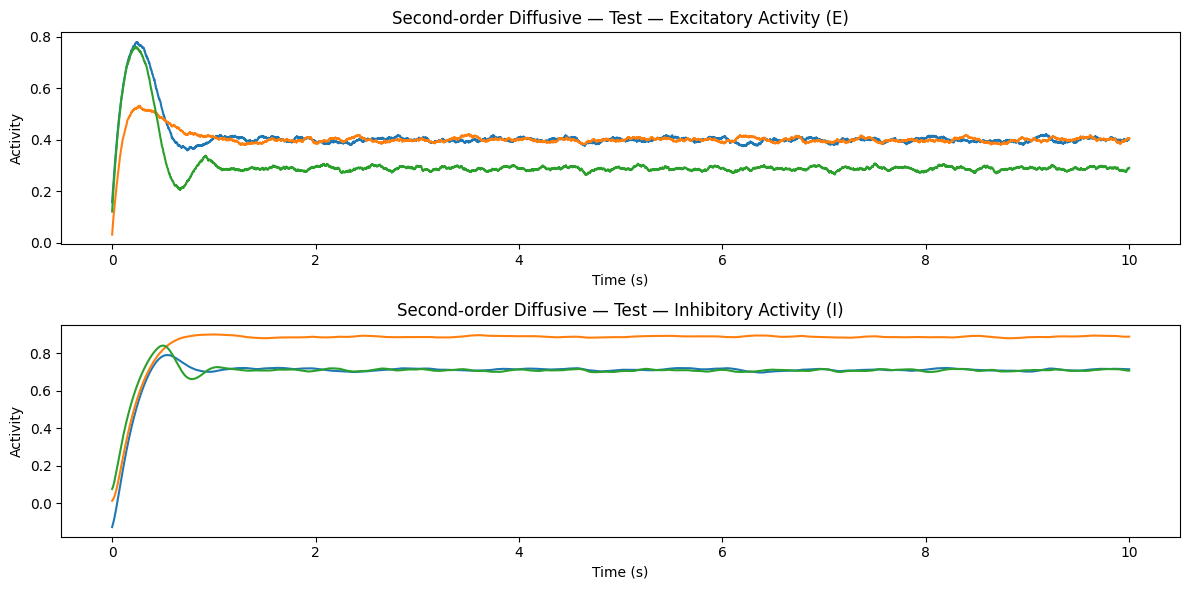

Total timesteps : 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.4000, std=0.0081, range=[0.3754, 0.4220]
  I: mean=0.7134, std=0.0055, range=[0.6978, 0.7234]

Node 1:
  E: mean=0.3996, std=0.0072, range=[0.3800, 0.4220]
  I: mean=0.8893, std=0.0037, range=[0.8809, 0.9013]

Node 2:
  E: mean=0.2887, std=0.0068, range=[0.2637, 0.3104]
  I: mean=0.7103, std=0.0048, range=[0.6999, 0.7271]


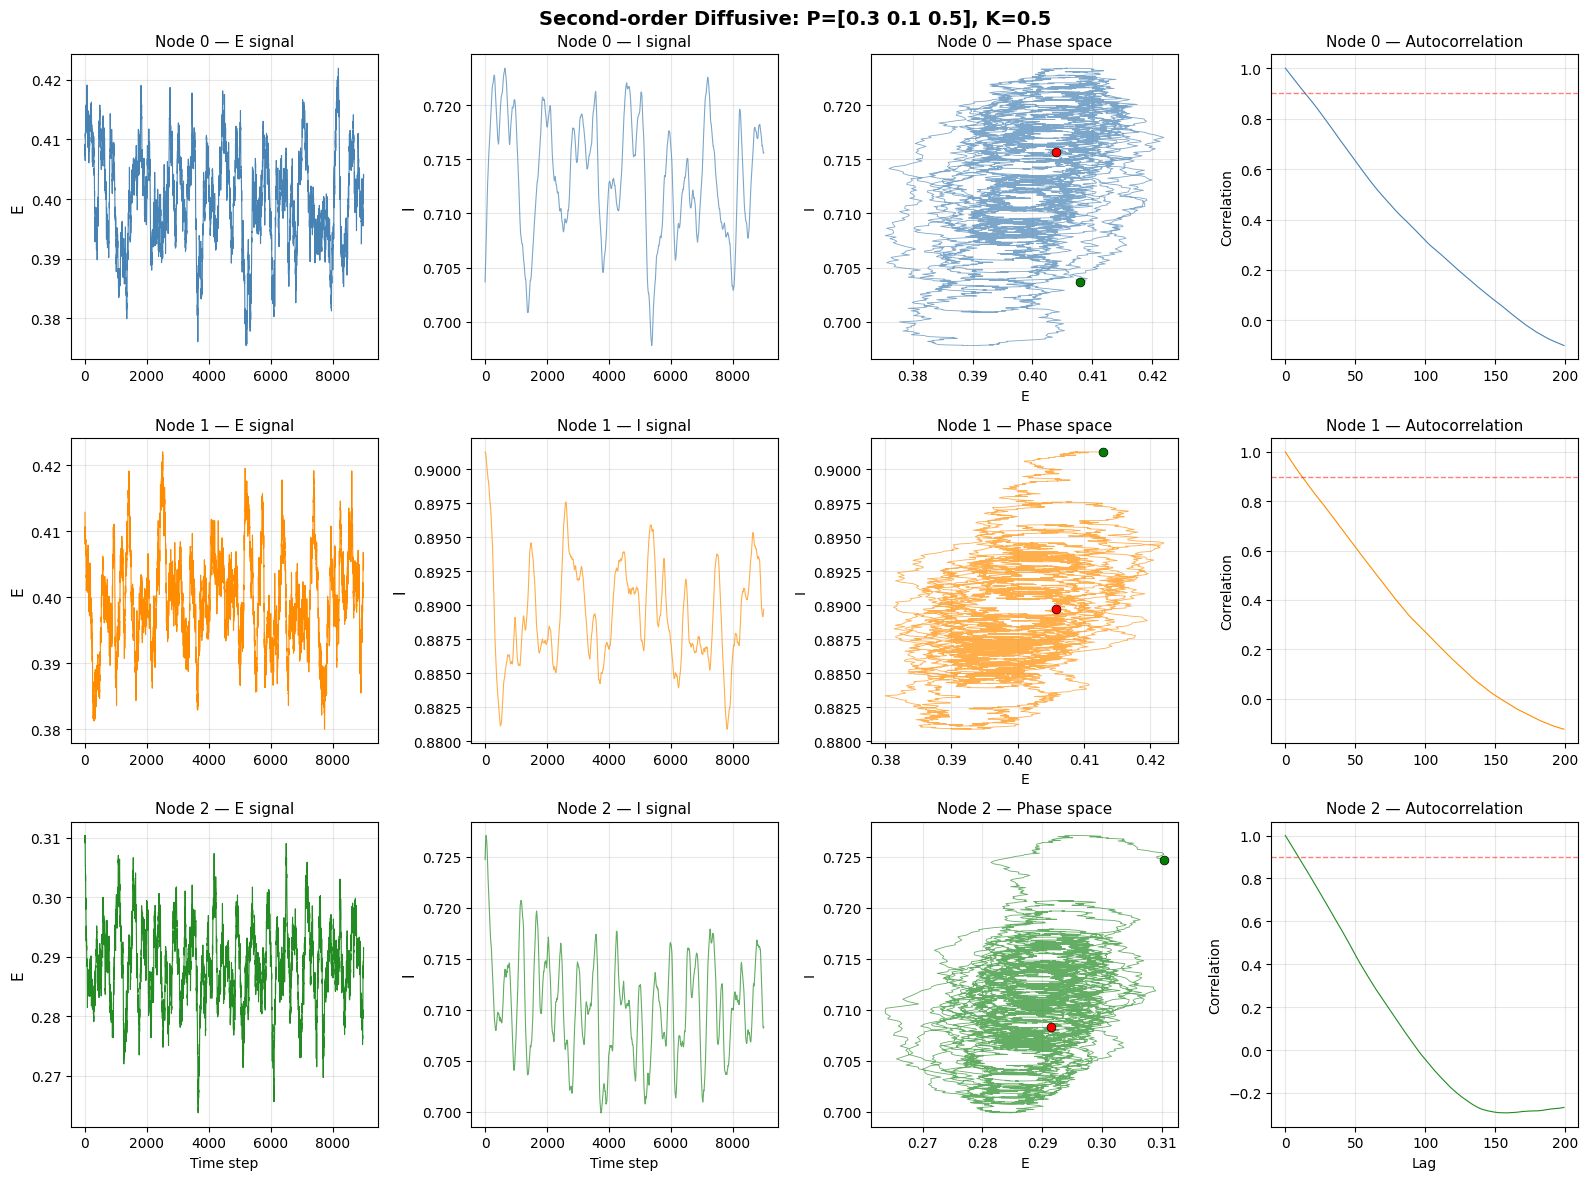

In [2]:
# Quick test simulation
A_sim = np.array([0.3, 0.1, 0.5])
K_sim = 0.5
state0 = 0.1 * np.random.randn(2 * N_nodes)
T = 10
sigma_E = 0.03

t, states = simulate_wc_additive_stochastic_a(state0, A_sim, K_sim, M, T, dt, sigma_E, P=7)

E = states[:, :N_nodes]
I = states[:, N_nodes:]

plot_signals(t, E, I, title="Second-order Diffusive — Test")
plot_detailed_signals(t, states, N_nodes, P_sim=A_sim, K_sim=K_sim, title="Second-order Diffusive")

---
## Parameter Sweep in $(a_E \times K)$ Space — with Stochastic Noise

Oscillation detection and higher-order metric computation across the full $(a_E, K)$ grid.

In [2]:
# Sweep parameters
A_values = np.linspace(0.5, 3, 20)
K_values = np.linspace(0.0, 1.0, 20)
K3_values = np.linspace(0.0, 1.0, 20)
sigma_E = 0.03
T = 375

# Storage matrices
oscillation_map_noise = np.zeros((len(A_values), len(K_values)), dtype=int)
TC_map_noise = np.zeros((len(A_values), len(K_values)))
DTC_map_noise = np.zeros((len(A_values), len(K_values)))
Cumulant_map_noise = np.zeros((len(A_values), len(K_values)))
PowerCorr_map_noise = np.zeros((len(A_values), len(K_values)))
Entropy_map_noise = np.zeros((len(A_values), len(K_values)))
Entropy_map_skew = np.zeros((len(A_values), len(K_values)))
Entropy_map_kurt = np.zeros((len(A_values), len(K_values)))

TC_ksg_map = np.zeros((len(A_values), len(K_values)))
DTC_ksg_map = np.zeros((len(A_values), len(K_values)))
Oinfo_ksg_map = np.zeros((len(A_values), len(K_values)))

# Fixed seed for reproducibility
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)

# Create folder for raw simulated signals
sim_folder = '../simulations/2nd_order_diffusive_ak'
os.makedirs(sim_folder, exist_ok=True)

for i, A_val in enumerate(A_values):
    for j, K_val in enumerate(K_values):
        A_vec = np.array([A_val, A_val, A_val])
        t, states = simulate_wc_additive_stochastic_a(
            state0, A_vec, K_val, M, T, dt, sigma_E, P=7
        )

        start_idx = int(0.2 * len(t))
        E_node = states[start_idx:, :N_nodes]
        I_node = states[start_idx:, N_nodes:]

        # Oscillation detection
        is_lc1, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt)
        is_lc2, _, _, _ = detect_limit_cycle_poincare(E_node[:, 1], I_node[:, 1], dt)
        is_lc3, _, _, _ = detect_limit_cycle_poincare(E_node[:, 2], I_node[:, 2], dt)
        oscillation_map_noise[i, j] = int(is_lc1 and is_lc2 and is_lc3)

        # Metrics
        E = states[start_idx:, :N_nodes]
        X = E.copy()
        Sigma = np.cov(X.T)

        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)
        skew, kurt = dev_gauss(X)
        Entropy_map_skew[i, j] = skew
        Entropy_map_kurt[i, j] = kurt
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

        # --- KSG non-parametric metrics ---
        if X.shape[1] == 3:
            TC_ksg_map[i, j] = TC_ksg(X)
            DTC_ksg_map[i, j] = DTC_ksg(X)
            Oinfo_ksg_map[i, j] = Oinfo_ksg(X)

        # --- Save raw simulated signals ---
        I_node_save = states[start_idx:, N_nodes:]
        np.savez_compressed(
            sim_folder + '/signals_i' + str(i).zfill(2) + '_j' + str(j).zfill(2) + '.npz',
            E=E, I=I_node_save,
            row_val=A_val, col_val=K_val
        )

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(A_values)}")

# Clean outliers
TC_clean = clean_rowwise_signed(TC_map_noise, n_std=2)
DTC_clean = clean_rowwise_signed(DTC_map_noise, n_std=2)
Cumulant_clean = clean_rowwise_signed(Cumulant_map_noise, n_std=2)
PowerCorr_clean = clean_rowwise_signed(PowerCorr_map_noise, n_std=2)
Skew_clean = clean_rowwise_signed(Entropy_map_skew, n_std=2)
Kurt_clean = clean_rowwise_signed(Entropy_map_kurt, n_std=2)

TC_ksg_clean = clean_rowwise_signed(TC_ksg_map, n_std=2)
DTC_ksg_clean = clean_rowwise_signed(DTC_ksg_map, n_std=2)
Oinfo_ksg_clean = clean_rowwise_signed(Oinfo_ksg_map, n_std=2)

# Quick visualisation
plot_metrics_contour(oscillation_map_noise, A_values, K3_values, title="Oscillation detection")
plot_metrics_contour(TC_clean, A_values, K3_values, title="Total Correlation (TC) with Noise")
plot_metrics_contour(DTC_clean, A_values, K3_values, title="Dual Total Correlation (DTC) with Noise")
plot_metrics_contour(Cumulant_clean, A_values, K3_values, title="Third-Order Cumulant with Noise")
plot_metrics_contour(PowerCorr_clean, A_values, K3_values, title="Triple Power Correlation with Noise")

plot_metrics_contour(TC_ksg_clean, A_values, K3_values, title="TC KSG with Noise")
plot_metrics_contour(DTC_ksg_clean, A_values, K3_values, title="DTC KSG with Noise")
plot_metrics_contour(Oinfo_ksg_clean, A_values, K3_values, title="O-info KSG with Noise")

# ── Save cleaned results ──
np.savez_compressed(
    "../results/metrics_Pairwise_diffusive_noise_a.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_clean, DTC=DTC_clean,
    cumulant=Cumulant_clean, powercorr=PowerCorr_clean,
    skew=Skew_clean, kurt=Kurt_clean,
    TC_ksg=TC_ksg_clean, DTC_ksg=DTC_ksg_clean, Oinfo_ksg=Oinfo_ksg_clean,
    P=A_values, K3=K3_values,
)

# ── Save raw results ──
np.savez_compressed(
    "../results/raw_metrics_Pairwise_diffusive_noise_a.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_map_noise, DTC=DTC_map_noise,
    cumulant=Cumulant_map_noise, powercorr=PowerCorr_map_noise,
    skew=Entropy_map_skew, kurt=Entropy_map_kurt,
    TC_ksg=TC_ksg_map, DTC_ksg=DTC_ksg_map, Oinfo_ksg=Oinfo_ksg_map,
    P=A_values, K3=K3_values,
)

print("Saved: metrics_Pairwise_diffusive_noise_a.npz & raw_metrics_Pairwise_diffusive_noise_a.npz")

Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


Saved: metrics_Pairwise_diffusive_noise_a.npz & raw_metrics_Pairwise_diffusive_noise_a.npz
